In [1]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
from scipy.stats import dunnett
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


In [8]:
# PER ver.
fpath = 'data/labellar.xlsx'

sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df[s] = df
data_df.keys()

data_df_optogenetics = {}
for interest in  ['web SS41446','horntail SS51950','meteor SS35420']:
    df = data_df[interest]
    per_11 = df[(df['light'] == 1) & (df['retinal'] == 1)]['PER']
    per_01 = df[(df['light'] == 0) & (df['retinal'] == 1)]['PER']
    data_df_optogenetics[interest] = per_11
    pivot_df[interest] = per_11.mean()
    error_df[interest] = per_11.std()/np.sqrt(len(per_11))
    
df = data_df['web SS41446']
per_11 = df[(df['light'] == 1) & (df['retinal'] == 1)]['PER']
per_01 = df[(df['light'] == 0) & (df['retinal'] == 1)]['PER']
pivot_df['control'] = per_01.mean()
error_df['control'] = per_01.std()/np.sqrt(len(per_01))
data_df_optogenetics['control'] = per_01
data_df_optogenetics = pd.DataFrame({
    k: pd.Series(v).reset_index(drop=True)
    for k, v in data_df_optogenetics.items()
})

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

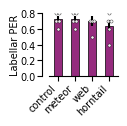

In [11]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

fontsize = 7
lp = 2

colors = ['#13739E', '#952B7E']

bar_spacing = 0.15
bar_width = 0.075


# ======================================
# 데이터 정리
# ======================================

mean_mat = pd.DataFrame.from_dict(
    pivot_df,
    orient='index'
)

mean_mat.columns = ['sugar']


std_mat = pd.DataFrame.from_dict(
    error_df,
    orient='index'
)

std_mat.columns = ['sugar']


# 원하는 순서
selected_order = [
    'control',
    'meteor SS35420',
    'web SS41446',
    'horntail SS51950'
]


mean_mat = mean_mat.loc[selected_order]
std_mat = std_mat.loc[selected_order]


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(0.9, BAR_H),
    constrained_layout=False
)


# ======================================
# Bar + scatter
# ======================================

xloc = draw_bar_with_points(
    ax=ax,

    conditions=selected_order,
    groups=['sugar'],

    get_values=lambda cond, group:
        data_df_optogenetics[cond],

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=[colors[1]],

    edgecolor='black',
    linewidth=.5,

    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=.3,
    point_size=5,
    point_alpha=.9
)


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[0]
    for x in selected_order
]


ax.set_xticks(
    xloc,
    xlabel,
    rotation=45,
    ha='right'
)


ax.set_yticks(
    np.arange(0, 1, .2)
)


ax.set_ylabel(
    'Labellar PER',
    labelpad=lp
)


ax.set_ylim([
    0,
    0.8
])


ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)


ax.spines[['top', 'right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward', 5)
)

ax.tick_params(
    pad=1
)

ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/Sufficiency_labial_barplot.svg'
# )

In [12]:
# PER ver.
fpath = 'data/tarsal.xlsx'

sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df[s] = df
data_df.keys()

data_df_optogenetics = {}
for interest in  ['web SS41446','horntail SS51950','meteor SS35420']:
    df = data_df[interest]
    per_11 = df[(df['light'] == 1) & (df['retinal'] == 1)]['PER']
    per_01 = df[(df['light'] == 0) & (df['retinal'] == 1)]['PER']
    data_df_optogenetics[interest] = per_11
    pivot_df[interest] = per_11.mean()
    error_df[interest] = per_11.std()/np.sqrt(len(per_11))
    
df = data_df['web SS41446']
per_11 = df[(df['light'] == 1) & (df['retinal'] == 1)]['PER']
per_01 = df[(df['light'] == 0) & (df['retinal'] == 1)]['PER']
pivot_df['control'] = per_01.mean()
error_df['control'] = per_01.std()/np.sqrt(len(per_01))
data_df_optogenetics['control'] = per_01
data_df_optogenetics = pd.DataFrame({
    k: pd.Series(v).reset_index(drop=True)
    for k, v in data_df_optogenetics.items()
})

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

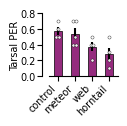

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

fontsize = 7
lp = 2

colors = ['#13739E', '#952B7E']

bar_spacing = 0.15
bar_width = 0.075


# ======================================
# 데이터 정리
# ======================================

mean_mat = pd.DataFrame.from_dict(
    pivot_df,
    orient='index'
)

mean_mat.columns = ['sugar']


std_mat = pd.DataFrame.from_dict(
    error_df,
    orient='index'
)

std_mat.columns = ['sugar']


# 원하는 순서
selected_order = [
    'control',
    'meteor SS35420',
    'web SS41446',
    'horntail SS51950'
]


mean_mat = mean_mat.loc[selected_order]
std_mat = std_mat.loc[selected_order]


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(0.9, BAR_H),
    constrained_layout=False
)


# ======================================
# Bar + scatter
# ======================================

xloc = draw_bar_with_points(
    ax=ax,

    conditions=selected_order,
    groups=['sugar'],

    get_values=lambda cond, group:
        data_df_optogenetics[cond],

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=[colors[1]],

    edgecolor='black',
    linewidth=.5,

    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=.3,
    point_size=5,
    point_alpha=.9
)


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[0]
    for x in selected_order
]


ax.set_xticks(
    xloc,
    xlabel,
    rotation=45,
    ha='right'
)


ax.set_yticks(
    np.arange(0, 1, .2)
)


ax.set_ylabel(
    'Tarsal PER',
    labelpad=lp
)


ax.set_ylim([
    0,
    0.8
])


ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)


ax.spines[['top', 'right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward', 5)
)

ax.tick_params(
    pad=1
)

ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/Sufficiency_tarsal_barplot.svg'
# )